In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

In [2]:
#Constants
gamma = 1.4 #Ratio of specific heats gamma = Cp/Cv
R = 8.314/0.022 #Universal gas constant (J/mol*K)
g0 = 9.81 #Standard gavity (m/s^2)
At = 0.01 #Nozzle throat area (m^2) -- 11cm diameter
Ae = 0.04 #Nozzle exit area (m^2) -- 22 cm diameter
Pc = 2e6  #Chamber pressure (Pa)
Tc = 3000 #Chamber temperature (K)
P0 = 101325 #Atmospheric pressure

In [3]:
# Area ratio
area_ratio = Ae / At

# Define the area-Mach relation rearranged to equal zero
def area_mach_relation(M):
    term = (2 / (gamma + 1)) * (1 + ((gamma - 1) / 2) * M**2)
    return area_ratio - (1/M) * term**((gamma + 1) / (2 * (gamma - 1)))

# Solve for exit Mach number
# Initial guess > 1 because we want the supersonic solution
Me = fsolve(area_mach_relation, x0=2.0)[0]

print(f"Area Ratio (Ae/At)  : {area_ratio:.2f}")
print(f"Exit Mach Number    : {Me:.4f}")

Area Ratio (Ae/At)  : 4.00
Exit Mach Number    : 2.9402


In [4]:
#Solving for Te and Pe using isotropic relations 

Te = Tc / (1 + ((gamma - 1) / 2) * Me ** 2)
Pe = Pc / (1 + ((gamma - 1) / 2) * Me ** 2) ** (gamma / (gamma - 1))

print(f"Exit Temperature (K): {Te:.2f}")
print(f"Exit Pressure (Pa) : {Pe:.2f}")

Exit Temperature (K): 1099.33
Exit Pressure (Pa) : 59573.93


In [5]:
#Finding the exit velocity using isentropic relations

Ve = np.sqrt((2 * gamma / (gamma - 1)) * R * Tc * (1 - (Pe / Pc) ** ((gamma - 1) / gamma)))

print(f"Exit Velocity (m/s^2): {Ve:.2f}")

Exit Velocity (m/s^2): 2242.31


In [6]:
#Calculating Specific Impulse, Thrust, and Mass Flow Rate

rh = (Pc * At / np.sqrt(Tc)) * np.sqrt((gamma / R) * (2 / (gamma + 1)) ** ((gamma + 1)/(2 * (gamma - 1))))
F = rh * Ve + (Pe - P0) * Ae
Isp = F / (rh * g0)

print(f"Mass Flow Rate (kg/s): {rh:.4f}")
print(f"Thrust (N)          : {F:.2f}")
print(f"Specific Impulse (s) : {Isp:.2f}")

Mass Flow Rate (kg/s): 16.9071
Thrust (N)          : 36240.82
Specific Impulse (s) : 218.50


In [7]:
# Generate area ratio arrays for both sections
AR_conv = np.linspace(2.0, 1.0, 100)  # converging: 2 down to 1
AR_div  = np.linspace(1.0, 4.0, 100)  # diverging: 1 up to 4

# Solve for Mach number at each area ratio
# Subsonic solution for converging (initial guess < 1)
# Supersonic solution for diverging (initial guess > 1)

M_conv = np.array([fsolve(lambda M: 
    ar - (1/M) * ((2/(gamma+1)) * (1 + (gamma-1)/2 * M**2))**((gamma+1)/(2*(gamma-1))),
    x0=0.5)[0] for ar in AR_conv])

M_div = np.array([fsolve(lambda M: 
    ar - (1/M) * ((2/(gamma+1)) * (1 + (gamma-1)/2 * M**2))**((gamma+1)/(2*(gamma-1))),
    x0=2.0)[0] for ar in AR_div])

# Combine both sections
AR_full = np.concatenate([AR_conv, AR_div])
M_full  = np.concatenate([M_conv,  M_div])

# Calculate pressure and temperature distributions
T_full = Tc / (1 + ((gamma-1)/2) * M_full**2)
P_full = Pc / (1 + ((gamma-1)/2) * M_full**2)**(gamma/(gamma-1))

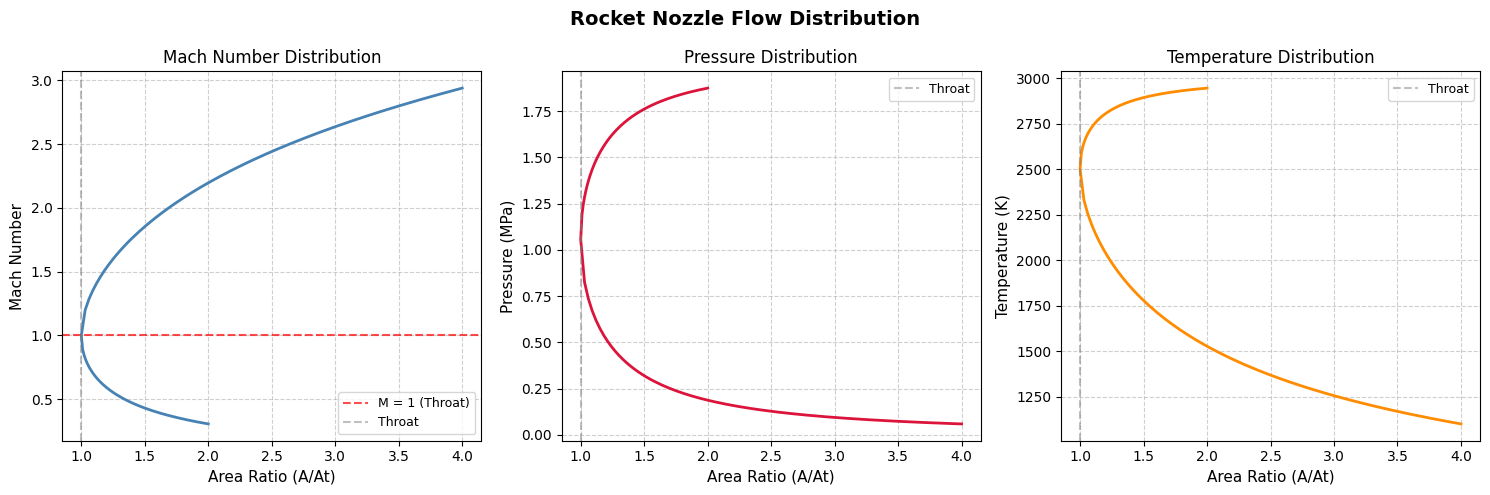

In [8]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Rocket Nozzle Flow Distribution', fontsize=14, fontweight='bold')

# Plot 1 - Mach Number
ax1.plot(AR_full, M_full, color='steelblue', linewidth=2)
ax1.axhline(y=1.0, color='red', linestyle='--', alpha=0.7, label='M = 1 (Throat)')
ax1.axvline(x=1.0, color='gray', linestyle='--', alpha=0.5, label='Throat')
ax1.set_xlabel('Area Ratio (A/At)', fontsize=11)
ax1.set_ylabel('Mach Number', fontsize=11)
ax1.set_title('Mach Number Distribution', fontsize=12)
ax1.legend(fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.6)

# Plot 2 - Pressure
ax2.plot(AR_full, P_full/1e6, color='crimson', linewidth=2)
ax2.axvline(x=1.0, color='gray', linestyle='--', alpha=0.5, label='Throat')
ax2.set_xlabel('Area Ratio (A/At)', fontsize=11)
ax2.set_ylabel('Pressure (MPa)', fontsize=11)
ax2.set_title('Pressure Distribution', fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(True, linestyle='--', alpha=0.6)

# Plot 3 - Temperature
ax3.plot(AR_full, T_full, color='darkorange', linewidth=2)
ax3.axvline(x=1.0, color='gray', linestyle='--', alpha=0.5, label='Throat')
ax3.set_xlabel('Area Ratio (A/At)', fontsize=11)
ax3.set_ylabel('Temperature (K)', fontsize=11)
ax3.set_title('Temperature Distribution', fontsize=12)
ax3.legend(fontsize=9)
ax3.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()